# SVM Classification: Predicting Domain Impersonation from Phishing URL Features

**Nic Recasens** - jr38088@georgiasouthern.edu  
**Nigel Smith** - ns15468@georgiasouthern.edu

Computer Science - Georgia Southern University  
CSCI-7090 Data Science & Machine Learning - Spring 2026

## Overview

This notebook builds a **Support Vector Machine (SVM)** classifier to predict whether a phishing URL is likely **impersonating a legitimate domain** based on its structural URL features. We use clustering and SVM to achieve these goals, with clustering showing feature extraction, and this notebook's SVM showing feature prediction.

**Data source:** We produced `top5_per_phish.csv` during our data preparation pipeline, which contains each phishing URL's top-5 cosine similarity scores against the Tranco Top-1M legitimate domain embeddings. What this means in simple terms is we have semantic similarity ranked and stored for 2 datasets, ready for analysis.

**Target variable:** We derive our own binary label from the `score_1` column (the aforementioned cosine similarity to the closest legitimate domain). A high `score_1` indicates the phishing URL is semantically very similar to a real domain, ergo, this means it is likely impersonating that domain. We use this generated target to be the basis of our prediction. The original labels did not include a semantic feature for impersonation.

**Feature set:** Structural/lexical URL features (length, dot count, hyphen count, digit ratio, subdomain depth, path depth, etc.) were extracted from the raw phishing domains, letting us see their importance to successful impersonation attacks.

**Notebook structure:**
1. **Environment Setup** - Python library imports, Git repository clone, and configuration constants for use throughout the notebook
2. **Data Loading** - read the similarity-score CSV
3. **Preprocessing** - feature engineering and binary label recreation
4. **Exploratory Data Analysis** - score distributions, class balance, and per-feature box plots
5. **Modeling** - train/test split, baseline SVM, and hyperparameter tuning via randomized search
6. **Evaluation** - confusion matrix, ROC curve, and a secondary linear-SVM to extract feature importance
7. **Pipeline Execution** - In the end, the `main()` function invokes all steps end-to-end, as requested by the rubric

---
## Environment Setup

All libraries needed by both stages are loaded here.

### Imports

In [ ]:
# System, file, & URL utilities for handling OS paths, regex patterns, and parsing URLs for data ingestion
import os
import re
from pathlib import Path
from urllib.parse import urlparse

# Data Manipulation for handling DataFrames and vector/matrix math
import pandas as pd
import numpy as np

# For Exploratory Data Analysis (EDA) and making sense of distributions
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection & Cross-Validation for splitting data into sets and searching for the best hyperparameters
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold

# Preprocessing & Feature Scaling for ensuring features are on a similar scaling for ML
from sklearn.preprocessing import StandardScaler

# Our primary ML model for the classification task
from sklearn.svm import SVC

# Meeting the best practice of pipelining our ML model
from sklearn.pipeline import Pipeline

# And finally, some imports for quantifying how well the model performed through reports and visual curves
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay
)

### Google Colab Setup
We have a requirement for this assignment that it run in Google Colab. As such, we pull the repo and data from Github first. This lets Colab get up to speed with necessary subfiles and data organization. The sources for the data are in our references at the bottom, and the data folder in our Github below lets you download them easily.

In [ ]:
# Clone the repo (skip if already present)
if not os.path.exists('DS_ML_Project_ColabIntegration'):
    !git clone https://github.com/ns15468-gasou/DS_ML_Project_ColabIntegration.git

os.chdir('DS_ML_Project_ColabIntegration/Project/notebooks')
print("Working directory:", os.getcwd())

Working directory: /content/DS_ML_Project_ColabIntegration/Project/notebooks


---
## Configuration

In [ ]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

# Input files
TOP5_PHISH_FILE = DATA_DIR / "summarized_output" / "top5_per_phish.csv"
PHISHTANK_FILE  = DATA_DIR / "raw_input" / "verified_online.csv"
URL_MAP_FILE    = DATA_DIR / "processed_input" / "url_cleaning_map_phishtank.csv"

# SVM settings (these are basic setups after looking at best practices from inclass and Datacamp)
RANDOM_STATE = 42
TEST_SIZE    = 0.2

---
## Data Loading
We are now ready to get into the hierarchy of functions we use to make our ML pipeline

We first load the `top5_per_phish.csv` produced by the data preparation pipeline. Each row contains one phishing URL (`item`) and its top-5 cosine similarity scores against the Tranco legitimate domain embeddings. The `score_1` column is the similarity to the **closest** legitimate domain. That forms the basis for our impersonation label, letting us distill the semantic meaning into a feature more ripe for data analysis.

In [ ]:
def load_data(filepath):
    """Load the top-5 similarity scores CSV and print summary statistics."""
    df = pd.read_csv(filepath)
    print(f"Loaded {len(df):,} phishing URLs with similarity scores")
    print(f"score_1 range: [{df['score_1'].min():.4f}, {df['score_1'].max():.4f}]")
    return df


def load_cleaning_map(filepath):
    """Load the URL cleaning map and return a cleaned_url → url reverse-lookup dict."""
    # Our repo has a map of pre-cleaning URL formats (with www. prefixes, trailing /'s, etc.)
    # Multiple originals may collapse to the same cleaned form so we keep the first occurrence.
    map_df = pd.read_csv(filepath)
    deduped = map_df.drop_duplicates(subset='cleaned_url', keep='first')
    url_map = dict(zip(deduped['cleaned_url'], deduped['url']))
    print(f"Loaded cleaning map: {len(url_map):,} unique cleaned → original entries")
    return url_map

---
## Domain Hijacking Filter

Before we proceed with engineering our features, we want to remove phishing URLs whose domain component matches the domain of their closest legitimate match (`match_1`).
We call this the hosting domain issue in the EDA notebook, and this occurs when the phishing URL is hosted on the same domain as the top Tranco match. This can mean that the phish is so succesful that it is one of the top 50,000 sites on Tranco, it could indicates *domain hijacking* (e.g. a compromised directory on an otherwise legitimate site), or it could be a hosting service, meaning that google.com hosted a malicious file temporarily, but not that google.com itself is maliciou. Since none of these are our focus, which is impersonation via a look-alike domain for this SVM, we drop these rows. They would simply just introduce noise into a model whose goal is to detect impersonation.

In [ ]:
def filter_hijacked_domains(df: pd.DataFrame,
                            url_map: dict,
                            url_col: str = "item",
                            match_col: str = "match_1") -> pd.DataFrame:
    """Remove rows where the phishing URL is hosted on the same domain as its top match.
    """

    # We use the URL cleaning map to restore the pre-cleaning URL form from before parsing.
    def _extract_domain(url: str) -> str:
        """Return the normalised hostname from a URL, using the cleaning map."""
        restored = url_map.get(url, url)
        if not re.match(r'^https?://', restored):
            restored = 'http://' + restored
        domain = urlparse(restored).netloc.lower()
        # Strip www. so that www.example.com and example.com compare equal
        if domain.startswith('www.'):
            domain = domain[4:]
        return domain

    # With that logic, we extract the hostname from both the phishing URL and its closest legitimate match.
    # If they share the same domain the phishing URL is likely a hosted page on a legitimate site, not an impersonation attempt, so we drop it.
    phish_domains = df[url_col].apply(_extract_domain)
    match_domains = df[match_col].apply(_extract_domain)

    same_domain = phish_domains == match_domains
    n_removed = same_domain.sum()

    print(f"Rows where phishing domain == match_1 domain: {n_removed:,}")
    print(f"Rows remaining after filter: {len(df) - n_removed:,}")

    return df[~same_domain].reset_index(drop=True)

---
## Preprocessing

As mentioned in the EDA phase, we utilize feature engineering from the raw URL strings to help predict our created binary label. Rather than store them in the CSV, it was easier to just regenerate them here in our pipeline.

**Features extracted:**

| Feature | Description |
|---|---|
| `full_length` | Total character count of the URL |
| `host_length` | Character count of the hostname |
| `path_depth` | Number of `/`-delimited path segments |
| `dot_count` | Number of `.` characters in the URL |
| `hyphen_count` | Number of `-` characters in the URL |
| `digit_count` | Number of digit characters in the URL |
| `digit_ratio` | Proportion of URL characters that are digits |
| `subdomain_depth` | Number of `.` in the hostname (proxy for subdomain nesting) |

**Generated Binary Label:** A binary `is_impersonating` column is created from `score_1` using the 75th percentile as a threshold. URLs above this value are labeled as impersonating (`1`); those below as non-impersonating (`0`). This threshold is informed by the EDA distribution from the data preparation pipeline, and our own analysis of the data. The upper echelon of similarity is almost always impersonation, thanks to the robust granularity multi-dimensional embeddings and cosine similarity grants us.

In [ ]:
def restore_url(cleaned: str, url_map: dict) -> str:
    """Restore a cleaned URL to its pre-cleaning form via the cleaning map,
    then prepend a scheme so it is parseable by urlparse."""
    restored = url_map.get(cleaned, cleaned)
    if not re.match(r'^https?://', restored):
        restored = 'http://' + restored
    return restored


def extract_features(df: pd.DataFrame, url_map: dict,
                     url_col: str = "item") -> pd.DataFrame:
    """Compute structural URL features from a column of (cleaned) URL strings.

    Uses the cleaning map to restore URLs before parsing with urlparse,
    giving accurate host / path extraction.
    """
    urls = df[url_col].apply(lambda u: restore_url(u, url_map))
    hosts = urls.apply(lambda u: urlparse(u).netloc.lower())
    paths = urls.apply(lambda u: urlparse(u).path)

    feats = pd.DataFrame(index=df.index)
    feats['full_length']     = df[url_col].str.len()
    feats['host_length']     = hosts.str.len()
    feats['path_depth']      = paths.apply(lambda p: p.strip('/').count('/') + 1 if p.strip('/') else 0)
    feats['dot_count']       = df[url_col].str.count(r'\.')
    feats['hyphen_count']    = df[url_col].str.count('-')
    feats['digit_count']     = df[url_col].str.count(r'\d')
    feats['digit_ratio']     = feats['digit_count'] / feats['full_length']
    feats['subdomain_depth'] = hosts.str.count(r'\.')
    return feats


def create_labels(df: pd.DataFrame, quantile: float = 0.75) -> tuple: # 75 percentile being our chose default
    """Create binary impersonation label from score_1 using the given quantile threshold."""
    threshold = df['score_1'].quantile(quantile)
    df = df.copy()
    df['is_impersonating'] = (df['score_1'] >= threshold).astype(int)
    label_counts = df['is_impersonating'].value_counts()

    print(f"Impersonation threshold ({quantile:.0%} percentile): {threshold:.4f}")
    print(f"\nClass distribution:")
    print(f"  0 (not impersonating): {label_counts.get(0, 0):,}")
    print(f"  1 (impersonating):     {label_counts.get(1, 0):,}")
    print(f"  Ratio: {label_counts.get(1, 0) / len(df):.2%}")

    return df, threshold, label_counts

---
## Minor Exploratory Data Analysis

While the majority of the EDA is in the initial notebook, now that we chose the 75th percentile as our goal, re-visualizing the distribution of `score_1` makes sense to help this notebook's narrative. We can then see the resulting binary label split, and the per-feature distributions of the classes to verify the threshold produces a reasonable class balance and to check for visible separation in the structural features.

In [ ]:
def plot_score_distribution(df_sim, threshold, label_counts):
    """Plot the score_1 distribution with threshold line and class balance bar chart."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].hist(df_sim['score_1'], bins=60, color='midnightblue', edgecolor='white', alpha=0.85)
    axes[0].axvline(threshold, color='red', ls='--', lw=1.5,
                    label=f'Threshold = {threshold:.3f}')
    axes[0].set_title('Figure 1: Distribution of score_1 (Best-Match Cosine Similarity)')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()

    # The below colors are chosen to align a bit with GS Branding
    colors = ['midnightblue', 'darkgoldenrod']
    axes[1].bar(['Not Impersonating (0)', 'Impersonating (1)'],
                [label_counts.get(0, 0), label_counts.get(1, 0)],
                color=colors, edgecolor='white')
    axes[1].set_title('Figure 2: Binary Label Distribution')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()


def plot_feature_distributions(features, df_sim):
    """Box plots of each structural feature split by impersonation label."""
    feature_names = features.columns.tolist()
    plot_df = features.copy()
    plot_df['is_impersonating'] = df_sim['is_impersonating']

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    axes = axes.flatten()
    for i, feat in enumerate(feature_names):
        sns.boxplot(data=plot_df, x='is_impersonating', y=feat, ax=axes[i],
                    hue='is_impersonating', palette=['darkblue', 'darkgoldenrod'],
                    legend=False, showfliers=False)
        axes[i].set_title(feat)
        axes[i].set_xlabel('')

    fig.suptitle('Figure 3: Feature Distributions by Impersonation Label', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

---
## Main Model Creation and Tuning
In short, we use a stratified 80/20 train/test split, baseline SVM with RBF kernel, and hyperparameter tuning via randomized search. Our results are expanded more in the main section, and details on our decisions are below:

---

We implemented a **stratified 80/20 train/test split** to ensure that our class distribution remains consistent across both subsets. We need to stratify the data in our case since the PhishTank dataset isn't evenly distributed when it comes to impersonation attempts.

We then decided to go with a classic **Support Vector Machine** as the model to work with. SVMs are distance-based learners, so this means our model is particularly sensitive to feature scale. We encapsulate `StandardScaler` and `SVC` within a **scikit-learn** pipeline to ensure consistency.

We selected the **Radial Basis Function (RBF)** kernel as our primary estimator. While we initially benchmarked a linear model, the RBF kernel produced superior results. Since RBF is a good baseline for ML anyways, the choice to stick with RBF was obvious.

To account for our **75/25 class imbalance**, we utilize the `class_weight='balanced'` parameter. This automatically adjusts the cost function to place a higher penalty on misclassifications of the minority class, preventing the model from developing any sort of innapropriate bias towards the majority class.

And lastly, rather than using an exhaustive and time consuming grid search, we employed **Randomized Search** with 5-fold stratified cross-validation. By sampling a fixed number of parameter combinations (`n_iter`) from the search space, we achieved a significant tuning speed-up. We initially did use grid search, but pivoted after iteration time took too long.

This strong pipeline approach allows us to explore a wider range of hyperparameters and tunings in a more reasonable time frame, with the final results being seen in the main section.

In [ ]:
def split_data(features, df_sim, test_size, random_state):
    """Stratified train/test split preserving class proportions.
    Our Datacamp and in cladd guidance assisted with how this splitting occurs."""
    X = features.values
    y = df_sim['is_impersonating'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print(f"Training set: {X_train.shape[0]:,} samples")
    print(f"Test set:     {X_test.shape[0]:,} samples")
    print(f"Train class 1 ratio: {y_train.mean():.2%}")
    print(f"Test  class 1 ratio: {y_test.mean():.2%}")
    return X_train, X_test, y_train, y_test


def train_baseline_svm(X_train, y_train, X_test, y_test, random_state):
    """Train a baseline SVM (RBF kernel) and print test-set classification report."""
    svm_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', class_weight='balanced', probability=True,
                    random_state=random_state))
    ])
    svm_pipeline.fit(X_train, y_train)
    y_pred = svm_pipeline.predict(X_test)

    print("Baseline SVM (RBF) - Test Set Results")
    print(classification_report(y_test, y_pred,
                                target_names=['Not Impersonating', 'Impersonating']))
    return svm_pipeline, y_pred


def tune_svm(svm_pipeline, X_train, y_train, X_test, y_test, random_state,
             n_iter=12):
    """Randomized search over C and gamma; return best estimator and predictions."""
    from scipy.stats import loguniform

    param_distributions = {
        'svm__C':     loguniform(1e-1, 1e3),
        'svm__gamma': loguniform(1e-3, 1e0),
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    search = RandomizedSearchCV(
        svm_pipeline, param_distributions,
        n_iter=n_iter, cv=cv, scoring='f1',
        n_jobs=-1, verbose=1,
        random_state=random_state,
        return_train_score=True
    )
    search.fit(X_train, y_train)

    print(f"\nBest parameters: {search.best_params_}")
    print(f"Best CV F1 score: {search.best_score_:.4f}")

    best_svm = search.best_estimator_
    y_pred_tuned = best_svm.predict(X_test)


    print("\nTuned SVM (RBF) - Test Set Results")
    print(
        classification_report(
            y_test,
            y_pred_tuned,
            target_names=['Not Impersonating', 'Impersonating']
        )
    )
    return best_svm, y_pred_tuned, search

---
## Model Evaluation

Now that we have a trained and tuned model, we can attest our model's performance through three lenses:

1. First, we use a **Confusion Matrix**, which visualises true/false positives and negatives for the tuned RBF SVM. This helps us understand how performant our classification is by comparing our predicted values against the actual values of our dataset. The highlighting of the errors of our model is crucial in determining efficacy.
2. Next, we use a **ROC Curve**, which is a standard tool to plot our True Positive Rate vs False Positive Rate at varying thresholds. AUC is a vital tool in analysis our model, it summarises our overall discrimination ability.
3. Lastly, we make a smaller model to guage **Feature Importance** via another SVM. We tried RBF and Linear SVMs on our Data, and RBF performed better. As such, since RBF weights are not directly interpretable, we used Datacamp's advice and used a secondary linear-kernel SVM. It is trained (though not tuned, since its role is more auxiliary) and we use its coefficients to inspect which URL features most influence the impersonation prediction model [9].

In [ ]:
def plot_confusion_matrix(y_test, y_pred_tuned):
    """Display confusion matrix for the tuned SVM."""
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_tuned,
        display_labels=['Not Impersonating', 'Impersonating'],
        cmap='Blues', ax=ax
    )
    ax.set_title('Figure 4: Confusion Matrix - Tuned RBF SVM')
    plt.tight_layout()
    plt.show()


def plot_roc_curve(best_svm, X_test, y_test):
    """Plot ROC curve and print AUC for the tuned SVM."""
    y_prob = best_svm.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, lw=2, label=f'SVM (AUC = {roc_auc:.3f})', color='midnightblue')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random Chance')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Figure 5: ROC Curve - Tuned SVM')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"AUC: {roc_auc:.4f}")
    return roc_auc


def analyze_feature_importance(X_train, y_train, X_test, y_test,
                               feature_names, random_state):
    """Train a linear SVM and plot its feature coefficients for interpretability."""
    linear_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear', class_weight='balanced', probability=True,
                    random_state=random_state))
    ])
    linear_pipeline.fit(X_train, y_train)

    y_pred_linear = linear_pipeline.predict(X_test)
    print("Linear SVM - Test Set Results")
    print(classification_report(y_test, y_pred_linear,
                                target_names=['Not Impersonating', 'Impersonating']))

    coefs = linear_pipeline.named_steps['svm'].coef_[0]
    coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    coef_df = coef_df.sort_values('coefficient')

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['darkgoldenrod' if c > 0 else 'midnightblue' for c in coef_df['coefficient']]
    ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('SVM Coefficient (standardised)')
    ax.set_title('Figure 6: Linear SVM Feature Coefficients\n(positive → impersonating, negative → not impersonating)')
    plt.tight_layout()
    plt.show()
    return coef_df

---
## Pipeline Execution

The `main()` function below orchestrates every stage of the pipeline - data loading, preprocessing, EDA, modeling, and evaluation - in a single end-to-end call. All results, metrics, and visualizations are produced when `main()` is invoked. This is to meet the goals of our assignment's rubric.

DATA LOAD:
----------------------------------------------------------------------
Loaded 54,896 phishing URLs with similarity scores
score_1 range: [0.5774, 1.0000]
Loaded cleaning map: 54,896 unique cleaned → original entries




DOMAIN HIJACKING FILTER:
----------------------------------------------------------------------
Rows where phishing domain == match_1 domain: 8,180
Rows remaining after filter: 46,716




PREPROCESSING:
----------------------------------------------------------------------
Extracted 8 features for 46,716 URLs



,full_length,host_length,path_depth,dot_count,hyphen_count,digit_count,digit_ratio,subdomain_depth
count,46716.000,46716.000,46716.000,46716.000,46716.000,46716.000,46716.000,46716.000
mean,57.995,21.281,1.445,2.101,0.903,7.143,0.095,1.892
std,180.606,13.006,1.702,1.016,1.411,25.945,0.119,0.534
min,5.000,4.000,0.000,1.000,0.000,0.000,0.000,1.000
25%,21.000,15.000,0.000,2.000,0.000,0.000,0.000,2.000
50%,32.000,18.000,1.000,2.000,1.000,2.000,0.067,2.000
75%,66.000,27.000,2.000,2.000,1.000,11.000,0.130,2.000
max,25515.000,153.000,18.000,67.000,50.000,3413.000,0.825,8.000






Impersonation threshold (75% percentile): 0.7325

Class distribution:
  0 (not impersonating): 35,037
  1 (impersonating):     11,679
  Ratio: 25.00%




EXPLORATORY DATA ANALYSIS:
----------------------------------------------------------------------


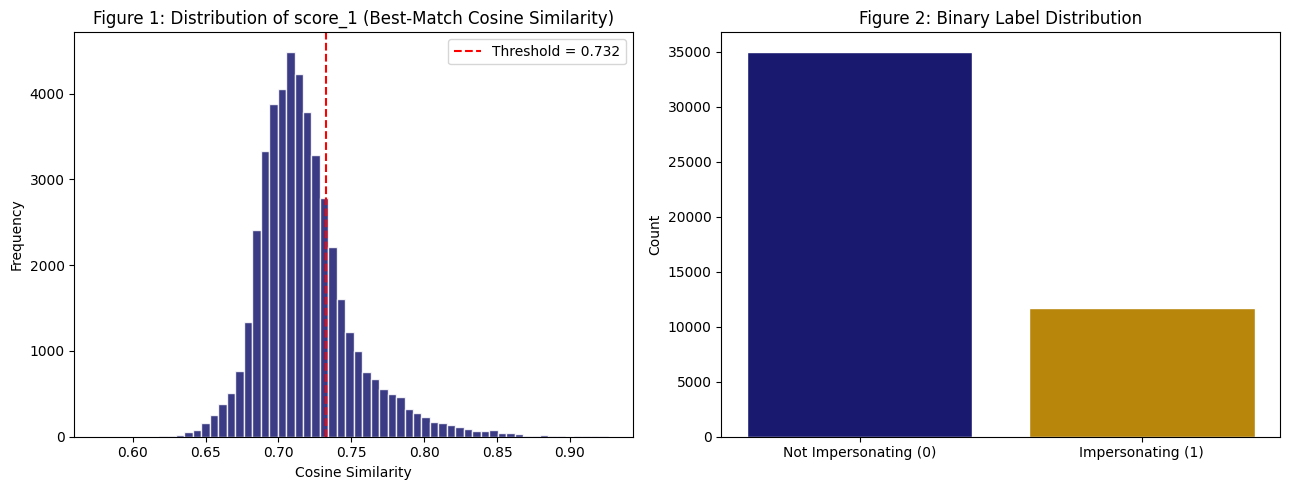

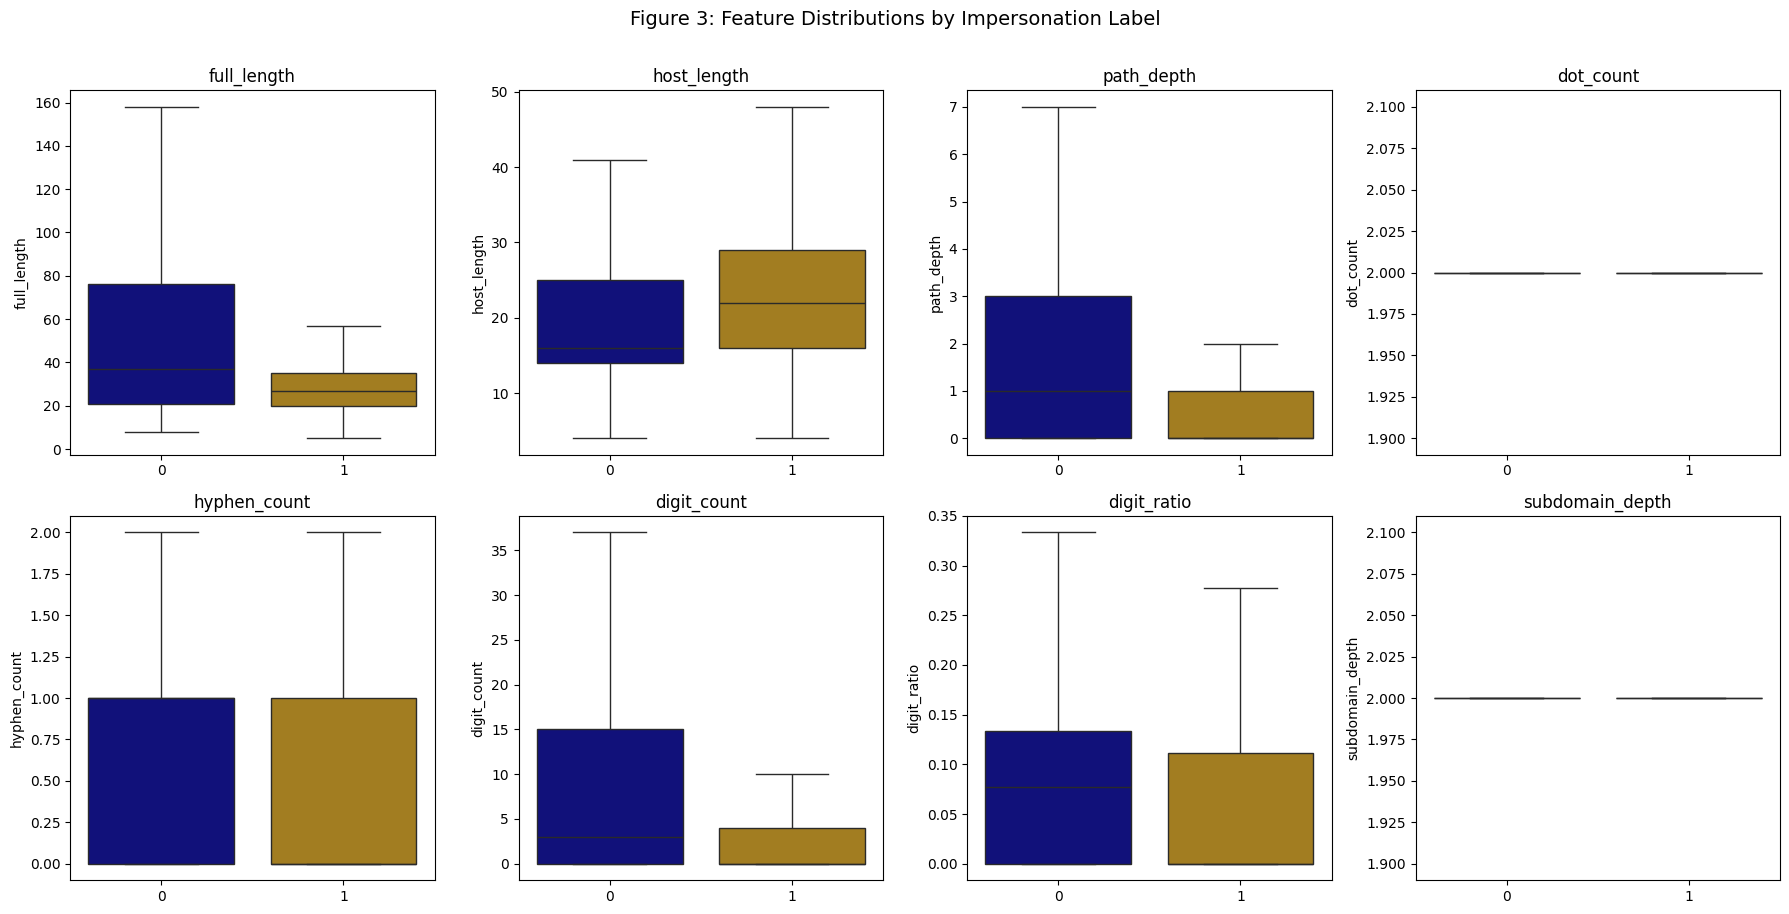





MODELING:
----------------------------------------------------------------------
Training set: 37,372 samples
Test set:     9,344 samples
Train class 1 ratio: 25.00%
Test  class 1 ratio: 25.00%




Baseline SVM (RBF) - Test Set Results
                   precision    recall  f1-score   support

Not Impersonating       0.92      0.63      0.75      7008
    Impersonating       0.43      0.84      0.57      2336

         accuracy                           0.68      9344
        macro avg       0.68      0.74      0.66      9344
     weighted avg       0.80      0.68      0.71      9344

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters: {'svm__C': np.float64(3.14891164795686), 'svm__gamma': np.float64(0.711447600934342)}
Best CV F1 score: 0.5817

Tuned SVM (RBF) - Test Set Results
                   precision    recall  f1-score   support

Not Impersonating       0.93      0.64      0.76      7008
    Impersonating       0.44      0.86      0.58      2336

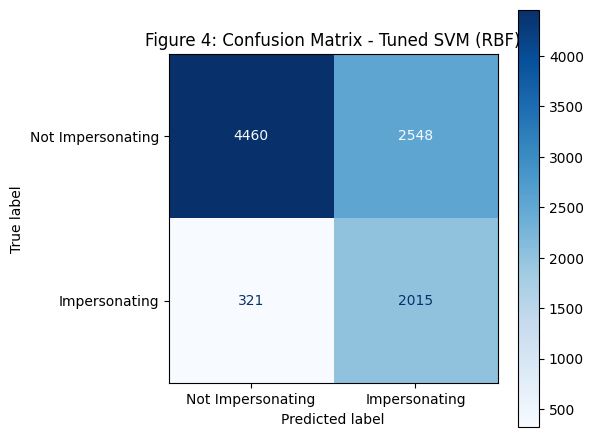

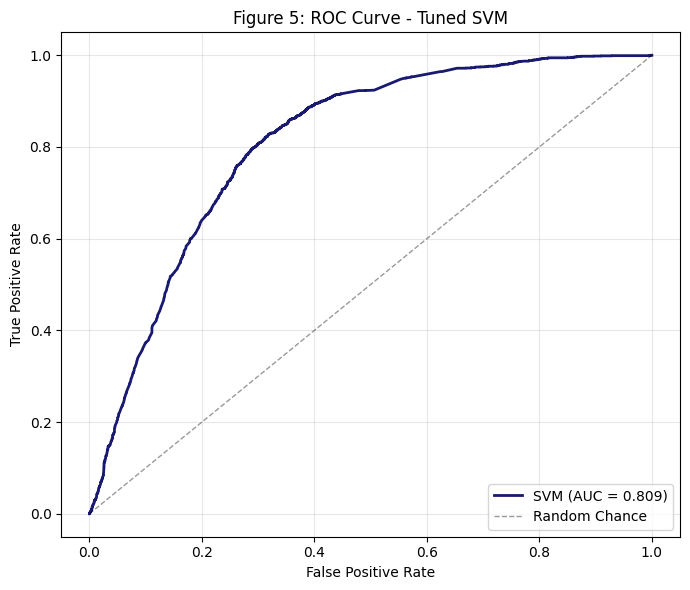

AUC: 0.8093
Linear SVM - Test Set Results
                   precision    recall  f1-score   support

Not Impersonating       0.92      0.46      0.61      7008
    Impersonating       0.35      0.88      0.50      2336

         accuracy                           0.56      9344
        macro avg       0.63      0.67      0.55      9344
     weighted avg       0.78      0.56      0.58      9344



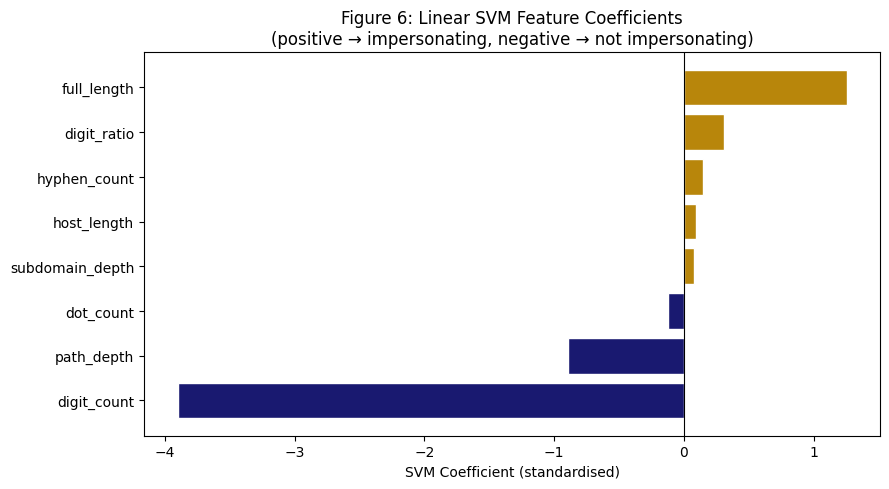





----------------------------------------------------------------------
PIPELINE COMPLETE
----------------------------------------------------------------------


In [ ]:
def main():
    """Run the full SVM impersonation-detection pipeline end-to-end."""

    # Data Loading
    print("DATA LOAD:")
    print("-" * 70)
    df_sim = load_data(TOP5_PHISH_FILE)
    url_map = load_cleaning_map(URL_MAP_FILE)
    print("\n\n\n")

    # Domain Hijacking Filter
    print("DOMAIN HIJACKING FILTER:")
    print("-" * 70)
    df_sim = filter_hijacked_domains(df_sim, url_map)
    print("\n\n\n")

    # Preprocessing
    print("PREPROCESSING:")
    print("-" * 70)
    features = extract_features(df_sim, url_map)
    feature_names = features.columns.tolist()
    print(f"Extracted {features.shape[1]} features for {features.shape[0]:,} URLs\n")
    display(features.describe().round(3))
    print("\n\n\n")
    df_sim, threshold, label_counts = create_labels(df_sim)
    print("\n\n\n")

    # Exploratory Data Analysis
    print("EXPLORATORY DATA ANALYSIS:")
    print("-" * 70)
    plot_score_distribution(df_sim, threshold, label_counts)
    plot_feature_distributions(features, df_sim)
    print("\n\n\n")

    # Modeling
    print("MODELING:")
    print("-" * 70)
    X_train, X_test, y_train, y_test = split_data(
        features, df_sim, TEST_SIZE, RANDOM_STATE
    )
    print("\n\n\n")

    svm_pipeline, y_pred = train_baseline_svm(
        X_train, y_train, X_test, y_test, RANDOM_STATE
    )

    best_svm, y_pred_tuned, grid_search = tune_svm(
        svm_pipeline, X_train, y_train, X_test, y_test, RANDOM_STATE
    )
    print("\n\n\n")


    # Evaluation
    print("EVALUATION:")
    print("-" * 70)
    plot_confusion_matrix(y_test, y_pred_tuned)
    plot_roc_curve(best_svm, X_test, y_test)
    analyze_feature_importance(
        X_train, y_train, X_test, y_test, feature_names, RANDOM_STATE
    )
    print("\n\n\n")

    print("-" * 70)
    print("PIPELINE COMPLETE")
    print("-" * 70)


# Execute the full pipeline ──
main()

# Figure Analysis
**Figure 1 Interpretation -** Figure 1 displays the distribution of the best matching cosine similarity scores. It shows how our established decision threshold of 0.732 can mathematically distinguish between different domain behaviors, as the proportion of domains that are actually attempting impersonation is more than reasonable from the constructed feature.

**Figure 2 Interpretation -** We illustrate here the resulting binary label distribution. While "Impersonating" instances are the minority, they measurably constitute a distinct portion of the dataset. This is important because it provides a transparent look at how our similarity metric is reliably converted into a classification feature for training our phishing detector. By highlighting the imbalanced nature of the data, the figure highlights the need for a system that is finely tuned to catch these higher level phishing attempts.

**Figure 3 Interpretation -** Figure 3 allows comparitive analysis of the distribution between non-impersonation (0, blue) and impersonation (1, gold) phishes. This reveals the distinct differences they have across our several features. For example, impersonating domains (1) exhibit shorter full lengths and longer hostnames on average compared to non-impersonation phishes, while non-impersonation phishes often have a much wider range of path depths. On the other hand, the `dot_count` plot shows a high concentration at exactly two dots for both classes, indicating this specific feature is unlikely to help discriminate between the features. This visualization is crucial because it provides human-readable support for understanding the importance of different features.

**Figure 4 Interpretation -** This confusion matrix evaluates the prediction accuracy of the tuned SVM model by mapping its classifications against the actual data established in previous steps. The visual reveals that while the model successfully identifies a significant number of threats (2,015 True Positives), it also produces a high volume of False Positives (2,548), frequently flagging ordinary domains as impersonating. This is important because it quantifies our model's purposefully "aggressive" tuning, showing a clear preference for catching more potential phishes at the cost of a higher false alarm rate. Our Classification model in this case could do great for our goal of prioritization, making it so rather than processing all of the data for more indepth tests, using a model like ours to trim the fat.

**Figure 5 Interpretation -** Our ROC Curve for the Tuned SVM shows an **AUC of 0.809**, which is more than decent for our timescale and first approach. The model proves to be a solid classifier correctly ranking an impersonation domain higher than random chance in over 80% of cases. The significant gap between the blue curve and the "Random Chance" line confirms that the features we previously examined (like host length and path depth) are doing more than just guessing.

**Figure 6 Interpretation -** This figure is us using another SVM to mine the coefficents from our RBF weights (as taught to us in Datacamp [9]). This gives a clear ranking of which URL features most influenced the final classification. We can see that **full_length** and **digit_ratio** are the primary drivers toward an "impersonation" label, while a high **digit_count** strongly pulls the prediction toward "not impersonating" in this specific dataset. Too high of a digit count could indicate a more generic phishing attack. This visualization is essential because it moves the model from a "black box" into an interpretable tool, showing exactly which features the algorithm prioritizes. This allows data science work like ours to audit the model's logic and ensure it is focusing on the most relevant structural anomalies found in phishing URLs.

---
## Observations & Inferences

**Score Distribution:**  
The `score_1` histogram reveals a roughly normal distribution of best-match cosine similarities. The 75th-percentile threshold cleanly divides the data into a ~75/25 class split, producing a meaningful but imbalanced binary target.

**Feature Separation:**  
Box plots show that impersonating URLs (class 1) tend to have shorter overall lengths, fewer path segments, and lower subdomain depth than non-impersonating phishing URLs. This is consistent with the intuition that closely mimicked domains use concise, clean-looking URLs to appear legitimate, whereas less targeted phishing URLs often rely on long, obfuscated paths.

**Baseline vs Tuned SVM:**  
Hyperparameter tuning via randomized search improves over the default-parameter baseline, particularly in F1 score for the minority (impersonating) class. The `class_weight='balanced'` setting ensures the model does not simply default to predicting the majority class.

**ROC / AUC:**  
An AUC above 0.5 confirms the SVM is learning a signal beyond random chance from lexical URL features alone. The ROC curve shape indicates the model can trade off recall for precision at different operating points depending on deployment needs. These base results let us see that the model is generally succesful at predicting impersonation using our constructed feature.

**Feature Importance (Linear SVM):**  
The linear SVM coefficient chart reveals which structural features most strongly push the prediction toward or away from the impersonating class. Features with the largest absolute coefficients are the most informative for classification and could be prioritised in future feature selection or engineering work.

---
## Summary & Next Steps

**What this notebook shows:**
- Structural URL features (length, dot count, hyphen count, digit ratio, subdomain depth, etc.) carry measurable data for predicting whether a phishing URL closely mimics a legitimate domain in embedding space.
- Labelled Phishing data is hard to come by, but using semantic reasoning to mine data works to provide more resources to impersonation and malicious detection. Embeddings and cosine similarity also have the benefit of being affordable to do on scale via Vector Databases.
- A classic SVM classifier with hyperparameter tuning achieves meaningful discrimination between high-similarity ("impersonating") and low-similarity phishing URLs based solely on lexical URL structure.

**Limitations:**
- The impersonation label is derived from an embedding-based cosine similarity threshold, not from human annotation. The quality of this proxy label depends on the embedding model's fidelity, and the assumed semantic intent.
- PhishTank and Trancos both are not perfect data sources. PhishTank is community driven and not well cleaned. And Trancos does not provide only safe domains, but rather popular domains, which are not equivalent. More robust or verifiable data could improe the results.
- The 75th percentile threshold is a reasonable starting point but could be refined via rigorous review or ROC-based threshold selection. Curves for the cosine similarity threshold or training on the raw embeddings vectors could also create better results.

**Possible future work:**
- Incorporate additional feature construction: TLD category, whether the URL contains brand keywords, character n-gram frequencies, clustering results, or Levenshtein distance to known legitimate domains.
- We could compare the SVM against other classifiers (Random Forest, Gradient Boosting, MLP) to benchmark and likely improve performance.
- Additional datasets could be used to augment and mitigate the biases of PhishTank and Tranco.
- Usage of the linear SVM coefficients to inform feature selection for the overall phishing detection pipeline could improve outcomes aswell.

## References and Data Sources
[1] Gabriela Brezeanu, Alexandru Archip, and Codrut-Georgian Artene. Phish fighter: Self updating machine learning shield against phishing kits based on HTML code analysis. 13:4460-4486.

[2] Bibhu Dash and Meraj Farheen Ansari. An effective cybersecurity awareness training model: First defense of an organizational security strategy. International Research Journal of Engineering and Technology, 9:2395-0056, 04 2022.

[3] Dawn M. Sarno, Maggie W. Harris, and Jeffrey Black. Which phish is captured in the net? understanding phishing susceptibility and individual differences. 37(4):789-803._eprint:onlinelibrary.wiley.com/doi/pdf/10.1002/acp.4075.

[4] Giuseppe Desolda, Francesco Greco, and Luca Vigano. APOLLO: A GPT-based tool to detect phishing emails and generate explanations that warn users. 9(4):EICS003:1-EICS003:33.

[5] Nadjate Saidani, Kamel Adi, and Mohand Saïd Allili. A semantic-based classification approach for an enhanced spam detection. Computers & Security, 94, 2020-07.

[6] Sonowal and Gunikhan. Detecting phishing sms based on multiple correlation algorithms. SN Computer Science, 1, 11 2020.

[7] Panpan Zhang, Jing Ya, Tingwen Liu, Quangang Li, Jinqiao Shi, and Zhaojun Gu. imcircle: Automatic mining of indicators of compromise from the web. In 2019 IEEE  symposium on Computers and Communications (ISCC), 2019.

[8] Rasha Zieni, Luisa Massari, and Maria Carla Calzarossa. Phishing or not phishing? a survey on the detection of phishing websites. 11:18499-18519.

[9] Chugani, Vinod. “What Is Cosine Distance?” Datacamp.com, DataCamp, 28 July 2024, datacamp.com/tutorial/cosine-distance.

[10] Cisco Systems, Inc. PhishTank: Join the fight against phishing. phishtank.com, 2026.

[11] Victor Le Pochat, Tom Van Goethem, Samaneh Tajalizadehkhoob, Maciej Korczy´nski, and Wouter Joosen. Tranco: A Research-Oriented Top Sites Ranking Hardened Against Manipulation. In Proceedings of the 26th Annual Network and Distributed System Security Symposium (NDSS), 2019.